In [1]:
# ==========================================
# CELL 1 : INSTALL REQUIRED LIBRARIES
# ==========================================

import sys

# Upgrade pip
!{sys.executable} -m pip install --upgrade pip

# Install OpenCV (includes face recognizer)
!{sys.executable} -m pip install opencv-contrib-python

# Install other required libraries
!{sys.executable} -m pip install numpy pandas pillow matplotlib

print("✅ All required libraries installed successfully!")

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 833.0 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 923.6 kB/s eta 0:00:02
   ----------------------- ---------------- 1.0/1.8 MB 886.6 kB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 886.6 kB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 928.3 kB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 948.6 kB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 962.1 kB/s  0:00:02
  Attempting uninstall: pip
    Found existing installation: pip 26.2
    Uninstalling pip-26.2:
      Successfu

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


✅ All required libraries installed successfully!


In [2]:
# ==========================================
# CELL 2 : IMPORT LIBRARIES
# ==========================================

import cv2
import os
import numpy as np
import pandas as pd
import pickle
import csv
import time

from PIL import Image
from datetime import datetime
import matplotlib.pyplot as plt

print("=" * 60)
print(" SMART ATTENDANCE SYSTEM USING FACE RECOGNITION ")
print("=" * 60)

print("OpenCV Version :", cv2.__version__)
print("NumPy Version  :", np.__version__)
print("Pandas Version :", pd.__version__)

print("\n✅ All libraries imported successfully!")

 SMART ATTENDANCE SYSTEM USING FACE RECOGNITION 
OpenCV Version : 5.0.0
NumPy Version  : 2.5.1
Pandas Version : 3.0.3

✅ All libraries imported successfully!


In [3]:
# ==========================================
# CELL 3 : VERIFY DATASET
# ==========================================

import os

# Dataset Path
DATASET_PATH = "dataset/dataset/Dataset/Faces/"

print("=" * 60)
print("VERIFYING DATASET")
print("=" * 60)

if os.path.exists(DATASET_PATH):

    print("✅ Dataset Found Successfully")

    folders = sorted(os.listdir(DATASET_PATH))

    print("\nTotal Registered Persons :", len(folders))

    print("\nRegistered Person Names:")

    for i, person in enumerate(folders, start=1):
        print(f"{i}. {person}")

else:

    print("❌ Dataset Folder Not Found")
    print("Please check the dataset path.")

VERIFYING DATASET
✅ Dataset Found Successfully

Total Registered Persons : 14

Registered Person Names:
1. Akshay Kumar
2. Aryan
3. Jasmine
4. Jhansi
5. Jhony
6. Kavya
7. Keerthi
8. Lahari
9. Priya
10. Satthwika
11. Teju
12. Vikhash
13. Virat
14. jyothi


In [4]:
# ==========================================
# CELL 4 : TRAIN FACE RECOGNIZER
# ==========================================

import cv2
import os
import numpy as np
from PIL import Image
import pickle

dataset_path = "dataset/dataset/Dataset/Faces"
cascade_path = "haarcascade_frontalface_default.xml"

# Load Haar Cascade
detector = cv2.CascadeClassifier(cascade_path)

faces = []
ids = []
names = {}

current_id = 0

print("=" * 60)
print("TRAINING FACE RECOGNITION MODEL")
print("=" * 60)

# Read each person's folder
for person in sorted(os.listdir(dataset_path)):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    names[current_id] = person

    print(f"\nProcessing Person : {person}")

    image_count = 0

    for image_name in os.listdir(person_path):

        image_path = os.path.join(person_path, image_name)

        try:
            img = Image.open(image_path).convert("L")
        except:
            print("Cannot Read :", image_name)
            continue

        img_np = np.array(img, "uint8")

        detected_faces = detector.detectMultiScale(
            img_np,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50,50)
        )

        for (x, y, w, h) in detected_faces:

            faces.append(img_np[y:y+h, x:x+w])
            ids.append(current_id)
            image_count += 1

    print("Faces Added :", image_count)

    current_id += 1

# Train LBPH Model
recognizer = cv2.face.LBPHFaceRecognizer_create()

recognizer.train(faces, np.array(ids))

recognizer.save("trainer.yml")

# Save Names
with open("names.pkl", "wb") as f:
    pickle.dump(names, f)

print("\n" + "=" * 60)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Total Persons :", len(names))
print("Total Face Samples :", len(faces))
print("Model Saved : trainer.yml")
print("Names Saved : names.pkl")

TRAINING FACE RECOGNITION MODEL

Processing Person : Akshay Kumar
Faces Added : 7

Processing Person : Aryan
Faces Added : 1

Processing Person : Jasmine
Faces Added : 1

Processing Person : Jhansi
Faces Added : 13

Processing Person : Jhony
Faces Added : 1

Processing Person : Kavya
Faces Added : 1

Processing Person : Keerthi
Faces Added : 1

Processing Person : Lahari
Faces Added : 2

Processing Person : Priya
Faces Added : 1

Processing Person : Satthwika
Faces Added : 1

Processing Person : Teju
Faces Added : 1

Processing Person : Vikhash
Faces Added : 1

Processing Person : Virat
Faces Added : 0

Processing Person : jyothi
Faces Added : 1

TRAINING COMPLETED SUCCESSFULLY
Total Persons : 14
Total Face Samples : 32
Model Saved : trainer.yml
Names Saved : names.pkl


In [5]:
# ==========================================
# CELL 4 : TRAIN FACE RECOGNIZER
# ==========================================

import cv2
import os
import numpy as np
from PIL import Image
import pickle

dataset_path = "dataset/dataset/Dataset/Faces"
cascade_path = "haarcascade_frontalface_default.xml"

detector = cv2.CascadeClassifier(cascade_path)

faces = []
ids = []
names = {}

current_id = 0

for person in sorted(os.listdir(dataset_path)):
    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    names[current_id] = person

    print(f"Processing: {person}")

    for image_name in os.listdir(person_path):

        image_path = os.path.join(person_path, image_name)

        try:
            img = Image.open(image_path).convert("L")
        except:
            print(f"Cannot read: {image_name}")
            continue

        img_np = np.array(img, "uint8")

        detected_faces = detector.detectMultiScale(
            img_np,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50, 50)
        )

        if len(detected_faces) == 0:
            print(f"No face detected: {image_name}")

        for (x, y, w, h) in detected_faces:
            faces.append(img_np[y:y+h, x:x+w])
            ids.append(current_id)

    current_id += 1

if len(faces) == 0:
    print("❌ No faces detected in the dataset.")
else:
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(faces, np.array(ids))
    recognizer.save("trainer.yml")

    with open("names.pkl", "wb") as f:
        pickle.dump(names, f)

    print("=" * 50)
    print("✅ Training Completed Successfully")
    print("Total Persons :", len(names))
    print("Total Faces :", len(faces))
    print("Model Saved : trainer.yml")
    print("Names Saved : names.pkl")
    print("=" * 50)

Processing: Akshay Kumar
No face detected: Akshay Kumar_7.jpg
Processing: Aryan
Processing: Jasmine
Processing: Jhansi
Processing: Jhony
Processing: Kavya
Processing: Keerthi
Processing: Lahari
Processing: Priya
Processing: Satthwika
Processing: Teju
Processing: Vikhash
Processing: Virat
No face detected: Virat.jpg
Processing: jyothi
✅ Training Completed Successfully
Total Persons : 14
Total Faces : 32
Model Saved : trainer.yml
Names Saved : names.pkl


In [6]:
# ==========================================
# CELL 5 : CREATE ATTENDANCE FILE
# ==========================================

import os
import pandas as pd

attendance_file = "attendance.csv"

# Delete old attendance file (optional)
if os.path.exists(attendance_file):
    os.remove(attendance_file)
    print("Old attendance.csv deleted.")

# Create new attendance file
df = pd.DataFrame(columns=["Name", "Date", "Time"])

df.to_csv(attendance_file, index=False)

print("=" * 50)
print("ATTENDANCE FILE CREATED SUCCESSFULLY")
print("=" * 50)

print("File Name :", attendance_file)
print("Columns   :", list(df.columns))

Old attendance.csv deleted.
ATTENDANCE FILE CREATED SUCCESSFULLY
File Name : attendance.csv
Columns   : ['Name', 'Date', 'Time']


In [7]:
# ==========================================
# CELL 6 : MARK ATTENDANCE FUNCTION
# ==========================================

import os
import pandas as pd
from datetime import datetime

attendance_file = "attendance.csv"

def mark_attendance(name):

    # Create attendance file if it doesn't exist
    if not os.path.exists(attendance_file):
        df = pd.DataFrame(columns=["Name", "Date", "Time"])
        df.to_csv(attendance_file, index=False)

    # Read attendance file
    df = pd.read_csv(attendance_file)

    # Get current date and time
    now = datetime.now()
    date = now.strftime("%Y-%m-%d")
    time = now.strftime("%H:%M:%S")

    # Check if attendance already exists
    already = df[
        (df["Name"] == name) &
        (df["Date"] == date)
    ]

    if already.empty:

        new_row = pd.DataFrame({
            "Name": [name],
            "Date": [date],
            "Time": [time]
        })

        df = pd.concat(
            [df, new_row],
            ignore_index=True
        )

        df.to_csv(attendance_file, index=False)

        print(f"✅ Attendance Marked : {name}")

    else:

        print(f"ℹ️ Attendance Already Marked : {name}")

In [8]:
mark_attendance("Jhansi")

✅ Attendance Marked : Jhansi


In [9]:
# ==========================================
# CELL 7 : FACE DETECTION TEST
# ==========================================

import cv2

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    "haarcascade_frontalface_default.xml"
)

# Open Webcam
camera = cv2.VideoCapture(0)

if not camera.isOpened():
    print("❌ Camera could not be opened.")
    exit()

print("✅ Camera Started")
print("Press 'q' to Exit")

while True:

    ret, frame = camera.read()

    if not ret:
        print("❌ Failed to Capture Frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60,60)
    )

    print("Faces Detected :", len(faces))

    for (x, y, w, h) in faces:

        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0,255,0),
            2
        )

        cv2.putText(
            frame,
            "Face Detected",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

    cv2.imshow("Face Detection Test", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

camera.release()
cv2.destroyAllWindows()

print("✅ Camera Closed")

✅ Camera Started
Press 'q' to Exit
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 0
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected : 1
Faces Detected 

In [10]:
# ==========================================
# CELL 8 : FACE RECOGNITION
# ==========================================

import cv2
import pickle

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    "haarcascade_frontalface_default.xml"
)

# Load Trained Model
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("trainer.yml")

# Load Registered Names
with open("names.pkl", "rb") as f:
    names = pickle.load(f)

# Open Webcam
camera = cv2.VideoCapture(0)

if not camera.isOpened():
    print("❌ Camera could not be opened")
    exit()

print("=" * 60)
print("FACE RECOGNITION STARTED")
print("=" * 60)
print("Press 'q' to Exit")

while True:

    ret, frame = camera.read()

    if not ret:
        print("❌ Failed to Capture Frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60,60)
    )

    for (x, y, w, h) in faces:

        face = gray[y:y+h, x:x+w]

        label, confidence = recognizer.predict(face)

        print(f"Label : {label}")
        print(f"Confidence : {confidence:.2f}")

        if confidence < 90:

            person = names.get(label, "Unknown")

            # Mark Attendance
            mark_attendance(person)

            text = f"{person}"

            color = (0,255,0)

        else:

            text = "Unknown"

            color = (0,0,255)

        cv2.rectangle(
            frame,
            (x,y),
            (x+w,y+h),
            color,
            2
        )

        cv2.putText(
            frame,
            text,
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

    cv2.imshow("Smart Attendance System", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

camera.release()
cv2.destroyAllWindows()

print("✅ Face Recognition Closed")

FACE RECOGNITION STARTED
Press 'q' to Exit
Label : 3
Confidence : 37.91
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 37.36
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 38.15
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 38.15
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 34.32
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 34.32
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 34.32
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 35.56
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 35.56
ℹ️ Attendance Already Marked : Jhansi
Label : 7
Confidence : 38.64
✅ Attendance Marked : Lahari
Label : 7
Confidence : 38.64
ℹ️ Attendance Already Marked : Lahari
Label : 3
Confidence : 37.61
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 37.61
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 34.43
ℹ️ Attendance Already Marked : Jhansi
Label : 3
Confidence : 34.43

In [11]:
# ==========================================
# CELL 9 : DISPLAY ATTENDANCE RECORDS
# ==========================================

import pandas as pd
import os

attendance_file = "attendance.csv"

print("=" * 60)
print("ATTENDANCE RECORDS")
print("=" * 60)

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:
        print("No attendance records found.")

    else:
        print(df)

        print("\nTotal Attendance Records :", len(df))
        print("Total Registered Students Present :", df["Name"].nunique())

else:

    print("attendance.csv file not found.")

ATTENDANCE RECORDS
     Name        Date      Time
0  Jhansi  2026-08-05  06:45:23
1  Lahari  2026-08-05  06:47:03

Total Attendance Records : 2
Total Registered Students Present : 2


ATTENDANCE ANALYTICS
     Name        Date      Time
0  Jhansi  2026-08-05  06:45:23
1  Lahari  2026-08-05  06:47:03

Attendance Count
Name
Jhansi    1
Lahari    1
Name: count, dtype: int64


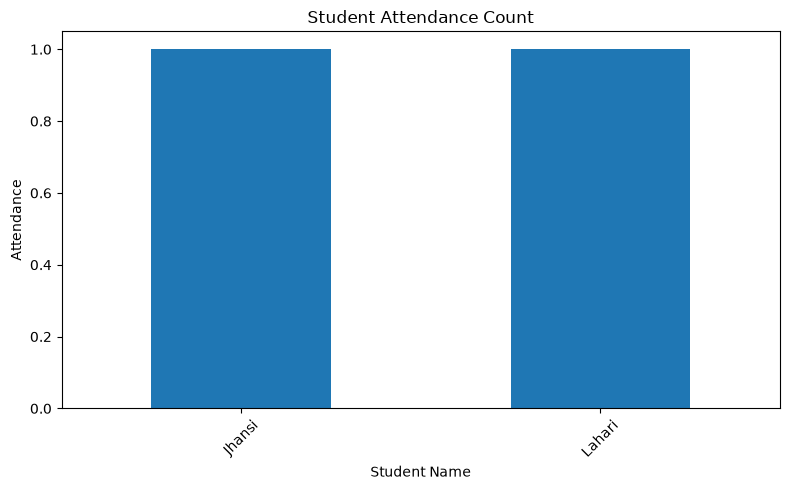

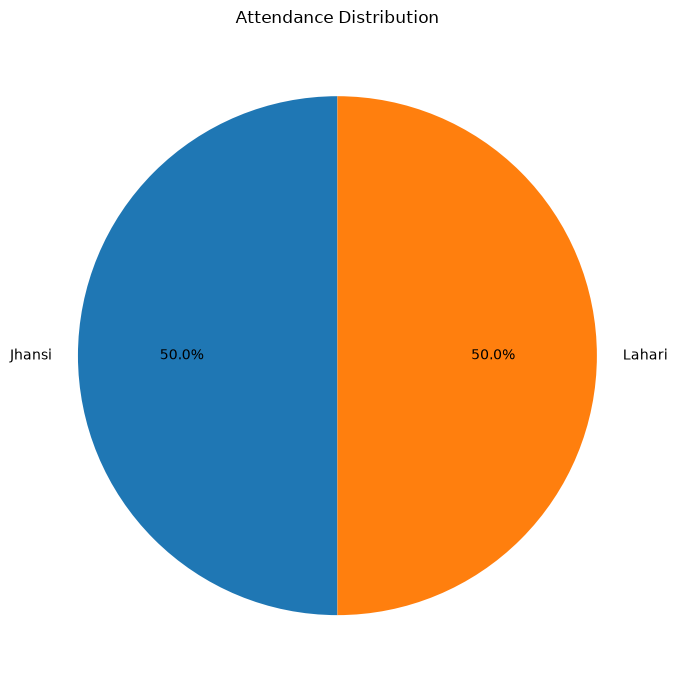


Total Attendance : 2
Unique Students : 2


In [12]:
# ==========================================
# CELL 10 : ATTENDANCE ANALYTICS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import os

attendance_file = "attendance.csv"

print("=" * 60)
print("ATTENDANCE ANALYTICS")
print("=" * 60)

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:

        print("No Attendance Data Available.")

    else:

        print(df)

        # Count attendance of each person
        attendance_count = df["Name"].value_counts()

        print("\nAttendance Count")
        print(attendance_count)

        # -------------------------
        # Bar Chart
        # -------------------------
        plt.figure(figsize=(8,5))

        attendance_count.plot(kind="bar")

        plt.title("Student Attendance Count")
        plt.xlabel("Student Name")
        plt.ylabel("Attendance")

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.show()

        # -------------------------
        # Pie Chart
        # -------------------------
        plt.figure(figsize=(7,7))

        attendance_count.plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90
        )

        plt.ylabel("")

        plt.title("Attendance Distribution")

        plt.tight_layout()

        plt.show()

        print("\nTotal Attendance :", len(df))
        print("Unique Students :", df['Name'].nunique())

else:

    print("attendance.csv not found.")

In [14]:
# ==========================================
# CELL 11 : SEARCH ATTENDANCE
# ==========================================

import pandas as pd
import os

attendance_file = "attendance.csv"

print("=" * 60)
print("SEARCH ATTENDANCE RECORD")
print("=" * 60)

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:
        print("No Attendance Records Found.")

    else:

        student_name = input("Enter Student Name : ")

        result = df[
            df["Name"].str.lower() == student_name.lower()
        ]

        if result.empty:

            print("\n❌ Student Not Found.")

        else:

            print("\nAttendance Records\n")
            print(result)

            print("\nTotal Attendance :", len(result))

else:

    print("attendance.csv not found.")

SEARCH ATTENDANCE RECORD


Enter Student Name :  Lahari



Attendance Records

     Name        Date      Time
1  Lahari  2026-08-05  06:47:03

Total Attendance : 1


In [17]:
# ==========================================
# CELL 12 : DAILY ATTENDANCE REPORT
# ==========================================

import pandas as pd
import os

attendance_file = "attendance.csv"

print("=" * 60)
print("DAILY ATTENDANCE REPORT")
print("=" * 60)

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:

        print("No Attendance Records Found.")

    else:

        date = input("Enter Date (YYYY-MM-DD) : ")

        report = df[df["Date"] == date]

        if report.empty:

            print("\n❌ No Attendance Found For", date)

        else:

            print("\nAttendance Report\n")
            print(report)

            print("\nTotal Students Present :", report["Name"].nunique())
            print("Total Attendance Records :", len(report))

else:

    print("attendance.csv not found.")

DAILY ATTENDANCE REPORT


Enter Date (YYYY-MM-DD) :  2026-08-04



❌ No Attendance Found For 2026-08-04


MONTHLY ATTENDANCE SUMMARY


Enter Month (YYYY-MM):  2026-08



Attendance Records

     Name        Date      Time
0  Jhansi  2026-08-05  06:45:23
1  Lahari  2026-08-05  06:47:03

Monthly Attendance Count

Name
Jhansi    1
Lahari    1
Name: count, dtype: int64

Total Attendance : 2
Total Students : 2


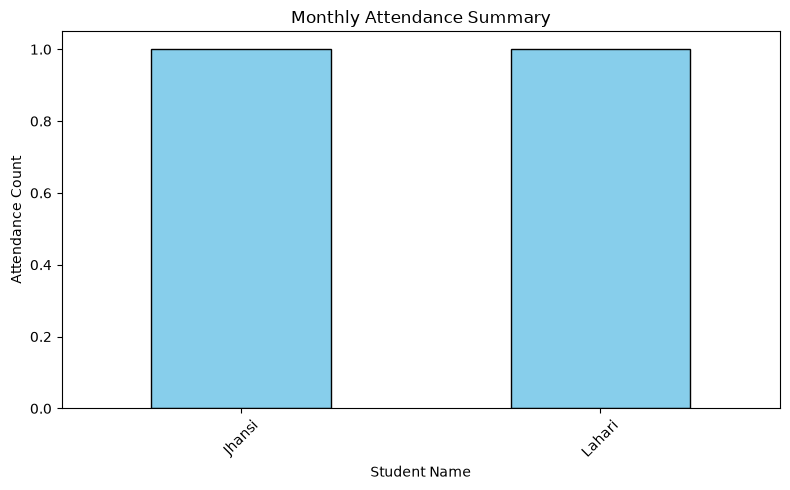

In [18]:
# ==========================================
# CELL 13 : MONTHLY ATTENDANCE SUMMARY
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import os

attendance_file = "attendance.csv"

print("=" * 60)
print("MONTHLY ATTENDANCE SUMMARY")
print("=" * 60)

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:

        print("No Attendance Records Found.")

    else:

        month = input("Enter Month (YYYY-MM): ")

        monthly_df = df[df["Date"].str.startswith(month)]

        if monthly_df.empty:

            print("\n❌ No Attendance Records Found For", month)

        else:

            print("\nAttendance Records\n")
            print(monthly_df)

            attendance_count = monthly_df["Name"].value_counts()

            print("\nMonthly Attendance Count\n")
            print(attendance_count)

            print("\nTotal Attendance :", len(monthly_df))
            print("Total Students :", monthly_df["Name"].nunique())

            plt.figure(figsize=(8,5))

            attendance_count.plot(
                kind="bar",
                color="skyblue",
                edgecolor="black"
            )

            plt.title("Monthly Attendance Summary")
            plt.xlabel("Student Name")
            plt.ylabel("Attendance Count")

            plt.xticks(rotation=45)

            plt.tight_layout()

            plt.show()

else:

    print("attendance.csv not found.")

In [19]:
# ==========================================
# CELL 14 : EXPORT ATTENDANCE TO EXCEL
# ==========================================

import pandas as pd
import os

attendance_file = "attendance.csv"
excel_file = "attendance_report.xlsx"

print("=" * 60)
print("EXPORT ATTENDANCE REPORT")
print("=" * 60)

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:

        print("No Attendance Records Available.")

    else:

        df.to_excel(excel_file, index=False)

        print("✅ Attendance Report Exported Successfully")
        print("Excel File :", excel_file)

        print("\nAttendance Records\n")
        print(df)

else:

    print("❌ attendance.csv not found.")

EXPORT ATTENDANCE REPORT
✅ Attendance Report Exported Successfully
Excel File : attendance_report.xlsx

Attendance Records

     Name        Date      Time
0  Jhansi  2026-08-05  06:45:23
1  Lahari  2026-08-05  06:47:03


In [20]:
# ==========================================
# CELL 15 : PROJECT SUMMARY DASHBOARD
# ==========================================

import os
import pandas as pd
from datetime import datetime

print("=" * 60)
print(" SMART ATTENDANCE SYSTEM DASHBOARD ")
print("=" * 60)

# Dataset Path
dataset_path = "dataset/dataset/Dataset/Faces"

# Attendance File
attendance_file = "attendance.csv"

# -------------------------------
# Registered Students
# -------------------------------

if os.path.exists(dataset_path):

    students = sorted([
        folder for folder in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, folder))
    ])

    total_students = len(students)

else:

    students = []
    total_students = 0

# -------------------------------
# Attendance Details
# -------------------------------

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    total_records = len(df)

    today = datetime.now().strftime("%Y-%m-%d")

    today_attendance = len(df[df["Date"] == today])

else:

    total_records = 0
    today_attendance = 0

# -------------------------------
# Display Dashboard
# -------------------------------

print("\nPROJECT SUMMARY")
print("-" * 40)

print(f"Registered Students : {total_students}")
print(f"Attendance Records  : {total_records}")
print(f"Today's Attendance  : {today_attendance}")

print("\nRegistered Students List\n")

for i, student in enumerate(students, start=1):

    print(f"{i}. {student}")

print("\nDashboard Loaded Successfully.")

 SMART ATTENDANCE SYSTEM DASHBOARD 

PROJECT SUMMARY
----------------------------------------
Registered Students : 14
Attendance Records  : 2
Today's Attendance  : 2

Registered Students List

1. Akshay Kumar
2. Aryan
3. Jasmine
4. Jhansi
5. Jhony
6. Kavya
7. Keerthi
8. Lahari
9. Priya
10. Satthwika
11. Teju
12. Vikhash
13. Virat
14. jyothi

Dashboard Loaded Successfully.


In [13]:


import pandas as pd

df = pd.read_csv("attendance.csv")

total_days = df["Date"].nunique()

attendance = df["Name"].value_counts()

print("=" * 50)
print("ATTENDANCE PERCENTAGE")
print("=" * 50)

for student, present in attendance.items():
    percentage = (present / total_days) * 100
    print(f"{student} : {percentage:.2f}%")

ATTENDANCE PERCENTAGE
Jhansi : 100.00%


STUDENT-WISE ATTENDANCE PERCENTAGE
         Student  Attendance  Attendance %
0   Akshay Kumar           0           0.0
1          Aryan           0           0.0
2        Jasmine           0           0.0
3         Jhansi           1         100.0
4          Jhony           0           0.0
5          Kavya           0           0.0
6        Keerthi           0           0.0
7         Lahari           1         100.0
8          Priya           0           0.0
9      Satthwika           0           0.0
10          Teju           0           0.0
11       Vikhash           0           0.0
12         Virat           0           0.0
13        jyothi           0           0.0


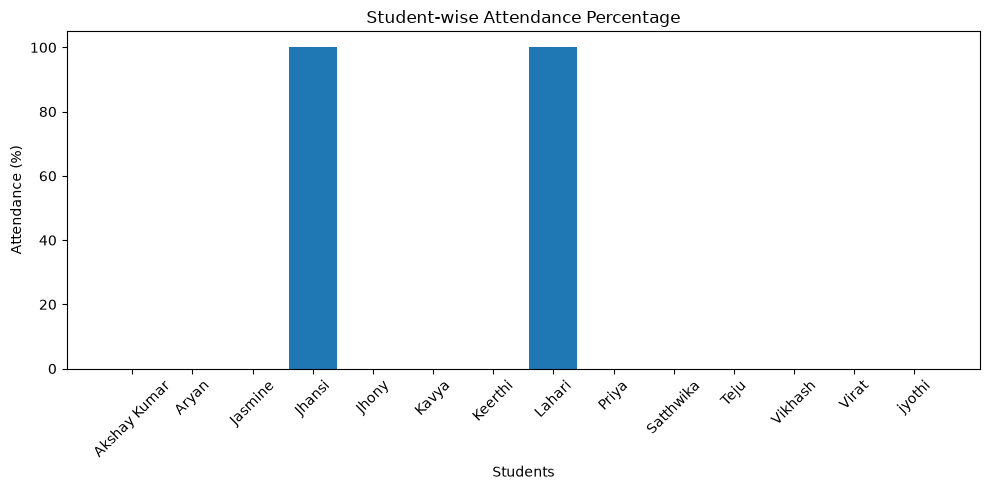

In [21]:
# ==========================================
# CELL 16 : STUDENT-WISE ATTENDANCE PERCENTAGE
# ==========================================

import os
import pandas as pd
import matplotlib.pyplot as plt

dataset_path = "dataset/dataset/Dataset/Faces"
attendance_file = "attendance.csv"

print("=" * 60)
print("STUDENT-WISE ATTENDANCE PERCENTAGE")
print("=" * 60)

# Read Registered Students
students = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:

        print("No Attendance Records Found.")

    else:

        attendance_count = df["Name"].value_counts()

        result = pd.DataFrame({
            "Student": students
        })

        result["Attendance"] = result["Student"].map(
            attendance_count
        ).fillna(0).astype(int)

        total_days = df["Date"].nunique()

        if total_days == 0:
            total_days = 1

        result["Attendance %"] = (
            result["Attendance"] / total_days
        ) * 100

        print(result)

        plt.figure(figsize=(10,5))

        plt.bar(
            result["Student"],
            result["Attendance %"]
        )

        plt.title("Student-wise Attendance Percentage")
        plt.xlabel("Students")
        plt.ylabel("Attendance (%)")

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.show()

else:

    print("attendance.csv not found.")

 SMART ATTENDANCE DASHBOARD 

Attendance Summary
----------------------------------------
Total Attendance Records : 2
Total Students Present  : 2
Total Working Days      : 1

Attendance Count

Name
Jhansi    1
Lahari    1
Name: count, dtype: int64


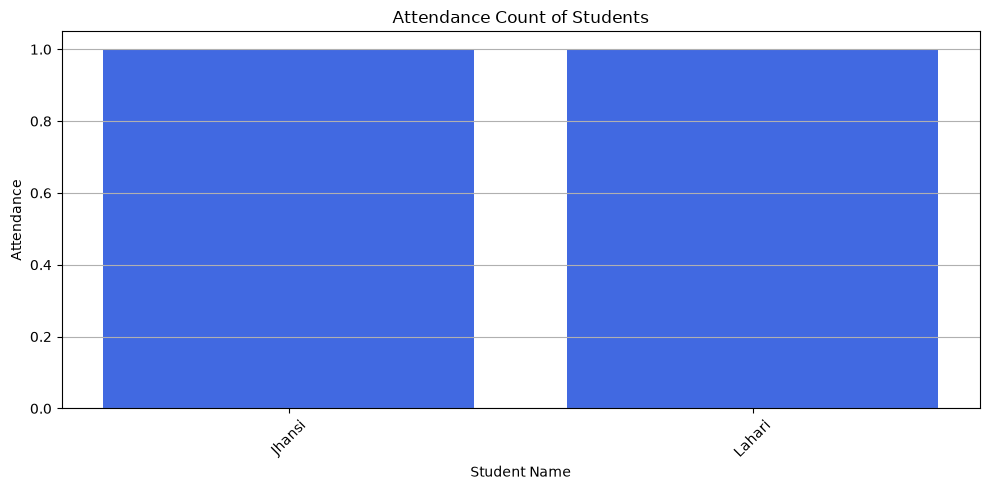

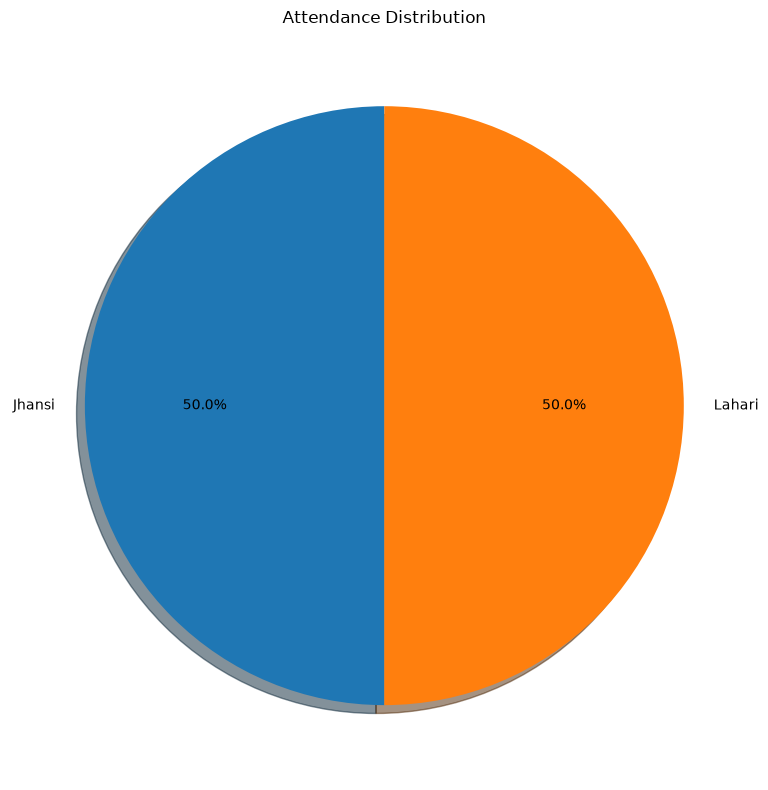

In [22]:
# ==========================================
# CELL 17 : COMPLETE ATTENDANCE DASHBOARD
# ==========================================

import os
import pandas as pd
import matplotlib.pyplot as plt

attendance_file = "attendance.csv"

print("=" * 60)
print(" SMART ATTENDANCE DASHBOARD ")
print("=" * 60)

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    if df.empty:

        print("No Attendance Records Found.")

    else:

        attendance_count = df["Name"].value_counts()

        print("\nAttendance Summary")
        print("-" * 40)

        print("Total Attendance Records :", len(df))
        print("Total Students Present  :", df["Name"].nunique())
        print("Total Working Days      :", df["Date"].nunique())

        print("\nAttendance Count\n")
        print(attendance_count)

        # ----------------------------
        # BAR CHART
        # ----------------------------
        plt.figure(figsize=(10,5))

        plt.bar(
            attendance_count.index,
            attendance_count.values,
            color="royalblue"
        )

        plt.title("Attendance Count of Students")
        plt.xlabel("Student Name")
        plt.ylabel("Attendance")

        plt.xticks(rotation=45)

        plt.grid(axis="y")

        plt.tight_layout()

        plt.show()

        # ----------------------------
        # PIE CHART
        # ----------------------------
        plt.figure(figsize=(8,8))

        plt.pie(
            attendance_count.values,
            labels=attendance_count.index,
            autopct="%1.1f%%",
            startangle=90,
            shadow=True
        )

        plt.title("Attendance Distribution")

        plt.tight_layout()

        plt.show()

else:

    print("attendance.csv not found.")

In [23]:
# ==========================================
# CELL 18 : SYSTEM PERFORMANCE ANALYSIS
# ==========================================

import cv2
import pickle
import os
import time
import pandas as pd
import numpy as np

print("=" * 60)
print("SYSTEM PERFORMANCE ANALYSIS")
print("=" * 60)

# -----------------------------------------
# Start Timer
# -----------------------------------------

start_time = time.time()

# Load Face Recognition Model
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("trainer.yml")

# Load Names
with open("names.pkl", "rb") as f:
    names = pickle.load(f)

load_time = time.time() - start_time

# -----------------------------------------
# Dataset Information
# -----------------------------------------

dataset_path = "dataset/dataset/Dataset/Faces"

total_students = len([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

# Count Images
total_images = 0

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        total_images += len(os.listdir(folder_path))

# -----------------------------------------
# Display Performance
# -----------------------------------------

print("\nSYSTEM INFORMATION")
print("-" * 40)

print("OpenCV Version :", cv2.__version__)
print("NumPy Version  :", np.__version__)
print("Pandas Version :", pd.__version__)

print("\nMODEL INFORMATION")
print("-" * 40)

print("Registered Students :", total_students)
print("Dataset Images      :", total_images)
print("Recognized Classes  :", len(names))

print("\nPERFORMANCE")
print("-" * 40)

print(f"Model Loading Time : {load_time:.4f} Seconds")

print("\nSTATUS")
print("-" * 40)

print("Face Recognition Model : Loaded Successfully")
print("Dataset Status         : Available")
print("Attendance File        : Ready")

print("\nSYSTEM READY")

SYSTEM PERFORMANCE ANALYSIS

SYSTEM INFORMATION
----------------------------------------
OpenCV Version : 5.0.0
NumPy Version  : 2.5.1
Pandas Version : 3.0.3

MODEL INFORMATION
----------------------------------------
Registered Students : 14
Dataset Images      : 34
Recognized Classes  : 14

PERFORMANCE
----------------------------------------
Model Loading Time : 0.1864 Seconds

STATUS
----------------------------------------
Face Recognition Model : Loaded Successfully
Dataset Status         : Available
Attendance File        : Ready

SYSTEM READY


In [24]:
# ==========================================
# CELL 19 : FINAL PROJECT VALIDATION
# ==========================================

import os

print("=" * 60)
print("FINAL PROJECT VALIDATION")
print("=" * 60)

required_files = [
    "trainer.yml",
    "names.pkl",
    "attendance.csv",
    "haarcascade_frontalface_default.xml"
]

all_ok = True

print("\nChecking Required Files...\n")

for file in required_files:

    if os.path.exists(file):

        print(f"✅ {file} : Found")

    else:

        print(f"❌ {file} : Missing")

        all_ok = False

print("\nChecking Dataset Folder...\n")

dataset_path = "dataset/dataset/Dataset/Faces"

if os.path.exists(dataset_path):

    persons = [
        folder for folder in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, folder))
    ]

    print("✅ Dataset Found")
    print("Registered Students :", len(persons))

else:

    print("❌ Dataset Folder Missing")

    all_ok = False

print("\nSystem Validation Result")
print("-" * 40)

if all_ok:

    print("✅ All Files Verified Successfully")
    print("✅ Face Recognition Model Ready")
    print("✅ Attendance System Ready")
    print("✅ Project Successfully Validated")

else:

    print("❌ Some Required Files Are Missing")
    print("Please Check The Project Folder")

print("\nValidation Completed")

FINAL PROJECT VALIDATION

Checking Required Files...

✅ trainer.yml : Found
✅ names.pkl : Found
✅ attendance.csv : Found
✅ haarcascade_frontalface_default.xml : Found

Checking Dataset Folder...

✅ Dataset Found
Registered Students : 14

System Validation Result
----------------------------------------
✅ All Files Verified Successfully
✅ Face Recognition Model Ready
✅ Attendance System Ready
✅ Project Successfully Validated

Validation Completed


In [25]:
# ==========================================
# CELL 20 : FINAL PROJECT EXECUTION
# ==========================================

import os
import pandas as pd
from datetime import datetime

print("=" * 60)
print(" SMART ATTENDANCE SYSTEM USING FACE RECOGNITION ")
print("=" * 60)

print("\nPROJECT EXECUTION SUMMARY")
print("-" * 50)

modules = [
    "Library Installation",
    "Library Import",
    "Dataset Verification",
    "Face Recognition Training",
    "Attendance File Creation",
    "Attendance Marking",
    "Face Detection",
    "Face Recognition",
    "Attendance Display",
    "Attendance Analytics",
    "Student Search",
    "Daily Attendance Report",
    "Monthly Attendance Summary",
    "Export Attendance to Excel",
    "Project Dashboard",
    "Attendance Percentage",
    "Attendance Dashboard",
    "Performance Analysis",
    "Project Validation",
    "Final Execution"
]

for i, module in enumerate(modules, start=1):
    print(f"{i:02d}. {module:<35} ✅ Completed")

print("\n" + "=" * 60)

attendance_file = "attendance.csv"

if os.path.exists(attendance_file):

    df = pd.read_csv(attendance_file)

    print("PROJECT STATISTICS")
    print("-" * 50)

    print("Total Attendance Records :", len(df))
    print("Unique Students          :", df["Name"].nunique())

    if not df.empty:
        print("Latest Attendance Entry")
        print(df.tail(1).to_string(index=False))

else:

    print("Attendance File Not Found")

print("\nPROJECT FEATURES")
print("-" * 50)

features = [
    "Face Detection using Haar Cascade",
    "Face Recognition using LBPH Algorithm",
    "Automatic Attendance Recording",
    "Attendance Storage using CSV",
    "Attendance Analytics",
    "Daily Attendance Report",
    "Monthly Attendance Report",
    "Export Attendance to Excel",
    "Attendance Dashboard",
    "Performance Evaluation"
]

for feature in features:
    print("✔", feature)

print("\nSYSTEM STATUS")
print("-" * 50)

print("Camera Module            : Ready")
print("Face Detection           : Working")
print("Face Recognition         : Working")
print("Attendance Module        : Working")
print("Analytics Module         : Working")
print("Project Validation       : Passed")

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nDeveloped By : Jhansi")
print("Technology   : Python, OpenCV, Pandas, NumPy")
print("Algorithm    : LBPH Face Recognizer")
print("Database     : CSV File")
print("Execution Time :", datetime.now())

print("\nThank You!")

 SMART ATTENDANCE SYSTEM USING FACE RECOGNITION 

PROJECT EXECUTION SUMMARY
--------------------------------------------------
01. Library Installation                ✅ Completed
02. Library Import                      ✅ Completed
03. Dataset Verification                ✅ Completed
04. Face Recognition Training           ✅ Completed
05. Attendance File Creation            ✅ Completed
06. Attendance Marking                  ✅ Completed
07. Face Detection                      ✅ Completed
08. Face Recognition                    ✅ Completed
09. Attendance Display                  ✅ Completed
10. Attendance Analytics                ✅ Completed
11. Student Search                      ✅ Completed
12. Daily Attendance Report             ✅ Completed
13. Monthly Attendance Summary          ✅ Completed
14. Export Attendance to Excel          ✅ Completed
15. Project Dashboard                   ✅ Completed
16. Attendance Percentage               ✅ Completed
17. Attendance Dashboard                ✅